**This notebook provide dataset overview and publication.**

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DEEP_TEAL     = "#2D4F54"
ROYAL_PURPLE  = "#7B539E"
SOFT_LAVENDER = "#B8A0D2"
FOREST_GREEN  = "#5A9448"
MUTED_PLUM    = "#9E4A78"
DARK_SLATE    = "#3A3D4A"

AIME_PALETTE = [
    DEEP_TEAL, ROYAL_PURPLE, SOFT_LAVENDER,
    FOREST_GREEN, MUTED_PLUM, DARK_SLATE,
]

AIME_RCPARAMS = {
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         11,

    "axes.facecolor":    "white",
    "axes.edgecolor":    DARK_SLATE,
    "axes.linewidth":    1.2,
    "axes.labelcolor":   DARK_SLATE,
    "axes.labelsize":    11,
    "axes.spines.top":   True,
    "axes.spines.right": True,
    "axes.prop_cycle":   plt.cycler("color", AIME_PALETTE),
    "axes.grid":         False,

    "xtick.color":         DARK_SLATE,
    "ytick.color":         DARK_SLATE,
    "xtick.labelsize":     9.5,
    "ytick.labelsize":     9.5,
    "xtick.major.width":   1.0,
    "ytick.major.width":   1.0,
    "xtick.major.size":    4.5,
    "ytick.major.size":    4.5,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.direction":     "out",
    "ytick.direction":     "out",

    "legend.frameon":    False,
    "legend.fontsize":   9.5,
    "legend.labelcolor": DARK_SLATE,

    "figure.facecolor":  "white",
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",

    "lines.linewidth":   1.8,
    "lines.markersize":  5.5,
}
plt.rcParams.update(AIME_RCPARAMS)

GLUE_STAT = Path("/Users/yaochenr/project/molecular_glue_extractor/data_source/250825_molglue_papers/mining_stat_20250825_164939.txt")
PROTAC_STAT = Path("/Users/yaochenr/project/molecular_glue_extractor/data_source/250825_protac_papers/mining_stat_20250825_144142.txt")
GT_COUNTS = {"MolGlue": 7, "PROTAC": 15}

def parse_stats(path: Path) -> dict:
    text = path.read_text()
    patterns = {
        "DOIs": r"Total DOIs:\s*(\d+)",
        "PMC": r"Found in PMC:\s*(\d+)",
        "Processed": r"Successfully processed \(Open Access\):\s*(\d+)",
    }
    return {k: int(re.search(p, text).group(1)) for k, p in patterns.items()}


protac = parse_stats(PROTAC_STAT) | {"GT": GT_COUNTS["PROTAC"]}
molglue = parse_stats(GLUE_STAT) | {"GT": GT_COUNTS["MolGlue"]}
protac, molglue


({'DOIs': 560, 'PMC': 303, 'Processed': 141, 'GT': 15},
 {'DOIs': 193, 'PMC': 108, 'Processed': 70, 'GT': 7})

In [2]:
import json

RESULTS_DIR = Path("/Users/yaochenr/project/molecular_glue_extractor/output/results")

PROTAC_BATCHES = [
    "260401_1036", "260401_1116", "260401_1420", "260401_1448", "260401_1531",
    "260401_1629", "260401_1714", "260401_1745", "260401_2101", "260401_2131",
    "260401_2157", "260401_2247", "260401_2322", "260401_2346",
]

GLUE_BATCHES = [
    "260304_0952", "260304_1043", "260304_1127", "260304_1240", "260304_1304",
    "active_prompting_batch_260131_2330/round_2/batch_results",
    "260201_0042",  
]


def unique_processed_chars(char_json: dict) -> int:
    return sum(
        r["paper_characters"]
        for r in char_json["rounds"]
        if r["round_type"] in ("main_text_extraction", "supplementary_extraction")
    )


def collect_cohort(batch_subdirs) -> dict:
    out = {}
    for sub in batch_subdirs:
        for fp in (RESULTS_DIR / sub).glob("**/character_length.json"):
            data = json.loads(fp.read_text())
            pmc = data["pmc_id"]
            chars = unique_processed_chars(data)
            if chars > out.get(pmc, 0):
                out[pmc] = chars
    return out


protac_chars = collect_cohort(PROTAC_BATCHES)
glue_chars = collect_cohort(GLUE_BATCHES)

print(f"PROTAC papers: {len(protac_chars)}  median={int(np.median(list(protac_chars.values())))}")
print(f"MolGlue papers: {len(glue_chars)}  median={int(np.median(list(glue_chars.values())))}")


PROTAC papers: 141  median=60289
MolGlue papers: 61  median=95908


In [3]:
import pandas as pd

GLUE_PMC_DIR = Path("/Users/yaochenr/project/molecular_glue_extractor/data_source/250825_molglue_papers")
PROTAC_PMC_DIR = Path("/Users/yaochenr/project/molecular_glue_extractor/data_source/250825_protac_papers")

GLUE_IDS = json.loads((GLUE_PMC_DIR / "paper_dois/avaliable_paper_ids.json").read_text())
PROTAC_IDS = json.loads((PROTAC_PMC_DIR / "paper_dois/avaliable_paper_ids.json").read_text())


def load_metadata(pmc_dir: Path, paper_ids: list, cohort: str) -> pd.DataFrame:
    rows = []
    for entry in paper_ids:
        pmc = entry["pmc_id"]
        meta_fp = pmc_dir / pmc / "metadata.json"
        if not meta_fp.exists():
            continue
        meta = json.loads(meta_fp.read_text())
        pubdate = meta.get("pubdate", "")
        year = int(pubdate[:4]) if pubdate[:4].isdigit() else None
        rows.append({
            "cohort": cohort,
            "pmc_id": pmc,
            "doi": entry["doi"],
            "year": year,
            "journal": meta.get("journal"),
        })
    return pd.DataFrame(rows)


meta_glue = load_metadata(GLUE_PMC_DIR, GLUE_IDS, "MolGlue-DB")
meta_protac = load_metadata(PROTAC_PMC_DIR, PROTAC_IDS, "PROTAC-DB")
meta_all = pd.concat([meta_protac, meta_glue], ignore_index=True)

print(f"PROTAC: {len(meta_protac)} papers ({meta_protac['year'].notna().sum()} with year)")
print(f"MolGlue: {len(meta_glue)} papers ({meta_glue['year'].notna().sum()} with year)")
print(f"Year range: {meta_all['year'].min():.0f} – {meta_all['year'].max():.0f}")
meta_all.head()


PROTAC: 141 papers (141 with year)
MolGlue: 70 papers (70 with year)
Year range: 2010 – 2025


,cohort,pmc_id,doi,year,journal
0,PROTAC-DB,PMC6348446,10.1021/acs.jmedchem.8b01413,2018,Journal of Medicinal Chemistry
1,PROTAC-DB,PMC6757289,10.1021/acschembio.9b00505,2019,ACS Chemical Biology
2,PROTAC-DB,PMC7552917,10.1039/d0sc00167h,2020,Chemical Science
3,PROTAC-DB,PMC10108347,10.1021/acs.jmedchem.2c01817,2023,Journal of Medicinal Chemistry
4,PROTAC-DB,PMC9729070,10.1016/j.bmcl.2022.128870,2022,Bioorganic & medicinal chemistry letters


In [4]:
CSV_DIR = Path("/Users/yaochenr/project/data/clean_data_csv")

PROTAC_FILES = {
    "Original":            ("26-04-28-original-protac-with-recordid.csv",   "Article DOI"),
    "Assay-Level":             ("26-04-24-PROTAC-Baseline-Final.csv",            "DOI"),
    "Endpoint": ("26-04-30-baseline-protacdb-processed-filtered-cleaned.csv", "DOI"),
}

GLUE_FILES = {
    "Original":            ("26-04-28-molglue-cleaned-with-recordid-1027.csv",  "SourceAddress_Website"),
    "Assay-Level":             ("glue_data/baseline/26-05-02-baseline-molgluedb-70.csv",     "DOI"),
    "Endpoint": ("glue_data/baseline/26-05-02-glue-baseline-processed.csv", "DOI"),
}

protac_dois = {e["doi"].lower() for e in PROTAC_IDS}
glue_dois = {e["doi"].lower() for e in GLUE_IDS}


def normalize_doi(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    for p in ("https://doi.org/", "http://doi.org/", "https://dx.doi.org/", "doi:"):
        if s.startswith(p):
            s = s[len(p):]
    return s


def stage_counts(file_map: dict, doi_set: set) -> dict:
    out = {}
    for stage, (fname, doi_col) in file_map.items():
        df = pd.read_csv(CSV_DIR / fname)
        kept = df[df[doi_col].map(normalize_doi).isin(doi_set)]
        out[stage] = len(kept)
    return out


protac_stages = stage_counts(PROTAC_FILES, protac_dois)
glue_stages = stage_counts(GLUE_FILES, glue_dois)
print("PROTAC :", protac_stages)
print("MolGlue:", glue_stages)


PROTAC : {'Original': 1969, 'Assay-Level': 2029, 'Endpoint': 376}
MolGlue: {'Original': 574, 'Assay-Level': 711, 'Endpoint': 136}


# Combined 1x4 figure


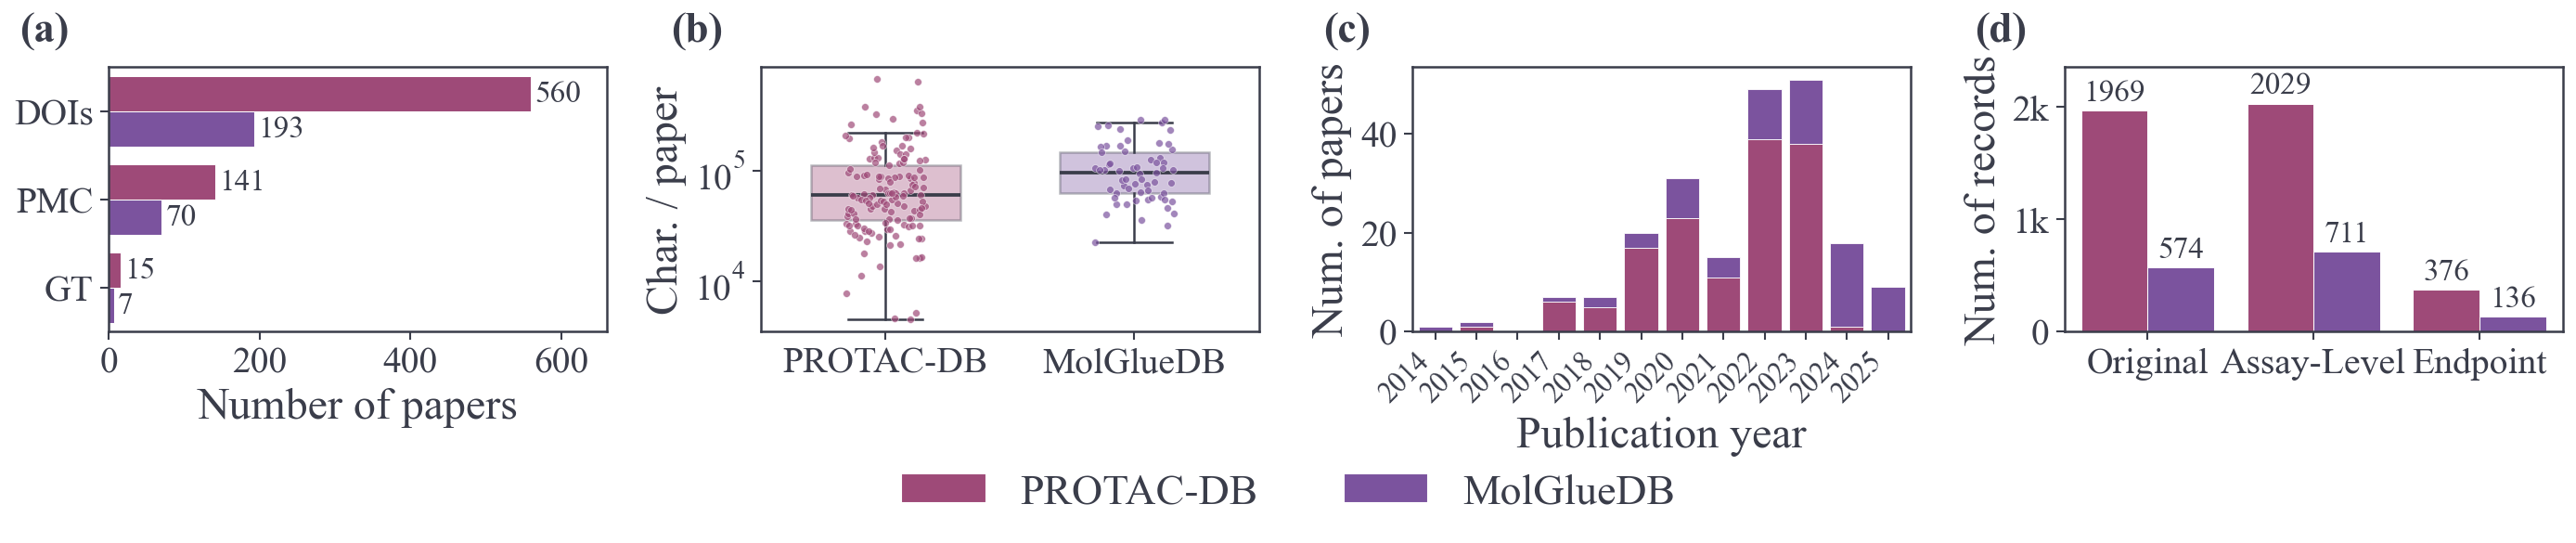

In [7]:
from matplotlib.ticker import NullLocator, FuncFormatter
from matplotlib.patches import Patch

C_PROTAC = MUTED_PLUM
C_GLUE = ROYAL_PURPLE

PAPER_FONT_RC = {
    "font.size":        23,
    "axes.labelsize":   23,
    "xtick.labelsize":  19,
    "ytick.labelsize":  19,
    "legend.fontsize":  22,
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
}


def add_panel_label(ax, label):
    ax.text(-0.18, 1.06, label, transform=ax.transAxes,
            fontsize=22, fontweight="bold", va="bottom", ha="left",
            color=DARK_SLATE)


with plt.rc_context(PAPER_FONT_RC):
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
    ax = axes[0]
    stages_a = ["DOIs", "Processed", "GT"]
    stages_a_labels = ["DOIs", "PMC", "GT"]
    pa = [protac[s] for s in stages_a]
    ga = [molglue[s] for s in stages_a]
    y = np.arange(len(stages_a))
    bh = 0.4
    b1 = ax.barh(y - bh / 2, pa, bh, color=C_PROTAC,
                 edgecolor="white", linewidth=0.5)
    b2 = ax.barh(y + bh / 2, ga, bh, color=C_GLUE,
                 edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(stages_a_labels)
    ax.invert_yaxis()
    ax.set_xlabel("Number of papers")
    for bars in (b1, b2):
        ax.bar_label(bars, padding=2, fontsize=16, color=DARK_SLATE)
    ax.set_xlim(0, max(pa) * 1.18)
    ax.set_ylim(len(stages_a) - 0.5, -0.5)
    add_panel_label(ax, "(a)")

    # (b) Unique processed characters per paper — boxplot + jitter
    ax = axes[1]
    data_b = [
        np.array(list(protac_chars.values()), dtype=float),
        np.array(list(glue_chars.values()), dtype=float),
    ]
    positions = [1, 2]
    bp = ax.boxplot(
        data_b, positions=positions, widths=0.6,
        patch_artist=True, showfliers=False,
        medianprops=dict(color=DARK_SLATE, linewidth=1.8),
        whiskerprops=dict(color=DARK_SLATE, linewidth=1.2),
        capprops=dict(color=DARK_SLATE, linewidth=1.2),
        boxprops=dict(linewidth=1.2),
    )
    for patch, c in zip(bp["boxes"], [C_PROTAC, C_GLUE]):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)
        patch.set_edgecolor(DARK_SLATE)
    rng = np.random.default_rng(0)
    for pos, vals, c in zip(positions, data_b, [C_PROTAC, C_GLUE]):
        jit = rng.uniform(-0.16, 0.16, size=len(vals))
        ax.scatter(pos + jit, vals, s=14, color=c, alpha=0.7,
                   edgecolor="white", linewidths=0.3, zorder=3)
    ax.set_yscale("log")
    ax.yaxis.set_minor_locator(NullLocator())
    ax.set_xticks(positions)
    ax.set_xticklabels(["PROTAC-DB", "MolGlueDB"])
    ax.set_ylabel("Char. / paper")
    ax.set_xlim(0.5, 2.5)
    add_panel_label(ax, "(b)")

    # (c) Publication year — stacked bar (from 2014)
    ax = axes[2]
    counts_c = (
        meta_all.dropna(subset=["year"])
        .astype({"year": int})
        .groupby(["year", "cohort"]).size()
        .unstack(fill_value=0)
    )
    year_min = 2014
    year_max = int(counts_c.index.max())
    years = np.arange(year_min, year_max + 1)
    counts_c = counts_c.reindex(years, fill_value=0)
    pc = counts_c.get("PROTAC-DB", pd.Series(0, index=years)).values
    gc = counts_c.get("MolGlue-DB", pd.Series(0, index=years)).values
    ax.bar(years, pc, width=0.82, color=C_PROTAC,
           edgecolor="white", linewidth=0.4)
    ax.bar(years, gc, bottom=pc, width=0.82, color=C_GLUE,
           edgecolor="white", linewidth=0.4)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha="right", fontsize=15)
    ax.set_xlim(year_min - 0.55, year_max + 0.55)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Num. of papers")
    add_panel_label(ax, "(c)")

    # (d) Database-derived records — grouped bar
    ax = axes[3]
    stages_d = list(PROTAC_FILES.keys())
    pd_y = [protac_stages[s] for s in stages_d]
    gd_y = [glue_stages[s] for s in stages_d]
    x = np.arange(len(stages_d))
    bw = 0.4
    d1 = ax.bar(x - bw / 2, pd_y, bw, color=C_PROTAC,
                edgecolor="white", linewidth=0.5)
    d2 = ax.bar(x + bw / 2, gd_y, bw, color=C_GLUE,
                edgecolor="white", linewidth=0.5)
    for bars in (d1, d2):
        ax.bar_label(bars, padding=2, fontsize=16, color=DARK_SLATE)
    ax.set_xticks(x)
    ax.set_xticklabels(stages_d)
    ax.set_xlim(-0.5, len(stages_d) - 0.5)
    ax.set_ylabel("Num. of records")
    ax.set_ylim(0, max(max(pd_y), max(gd_y)) * 1.16)

    def _kfmt(v, _):
        if v == 0:
            return "0"
        if v >= 1000:
            return f"{v / 1000:g}k"
        return f"{v:g}"

    ax.yaxis.set_major_formatter(FuncFormatter(_kfmt))
    add_panel_label(ax, "(d)")

    legend_handles = [
        Patch(facecolor=C_PROTAC, edgecolor="white", label="PROTAC-DB"),
        Patch(facecolor=C_GLUE, edgecolor="white", label="MolGlueDB"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(w_pad=0.6, rect=(0, 0.06, 1, 1))

    fig_dir = Path("figures")
    fig_dir.mkdir(exist_ok=True)
    fig.savefig(fig_dir / "data_overview.png")
    fig.savefig(fig_dir / "data_overview.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()


## Appendix top journals


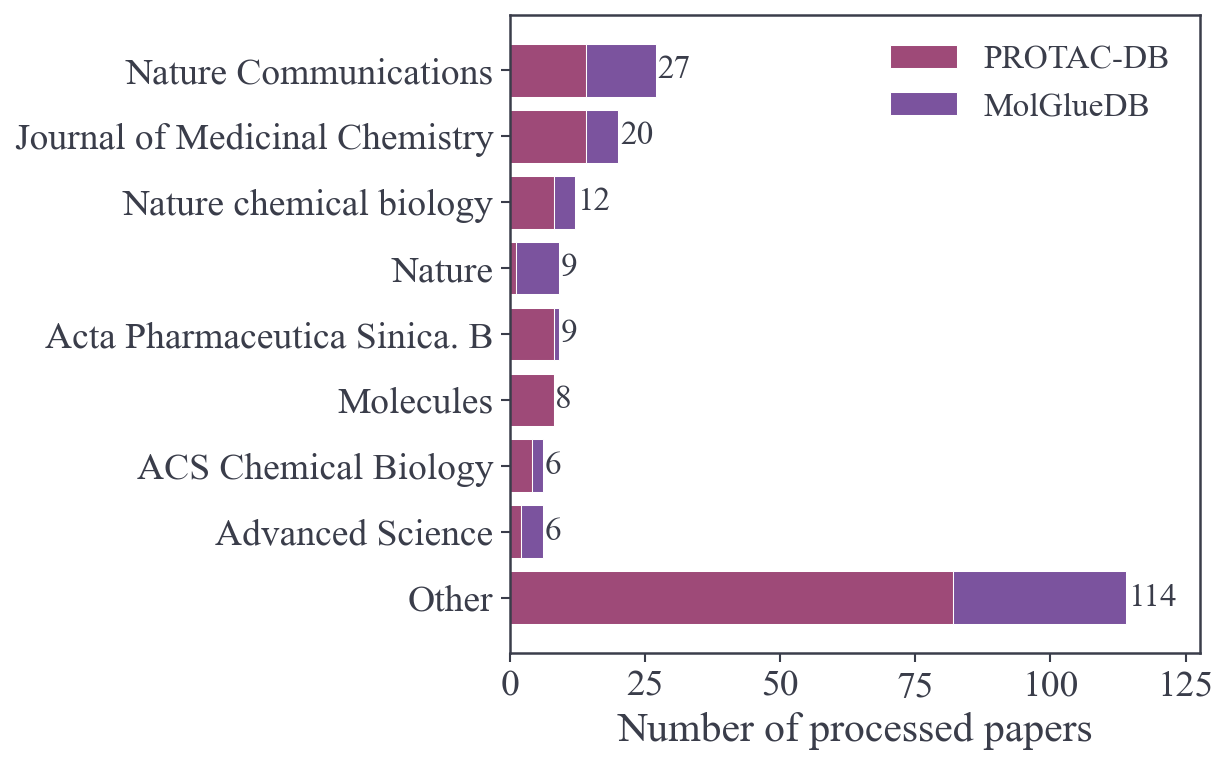

In [6]:
TOP_N = 8
PAPER_FONT_RC = {
    "font.size":        20,
    "axes.labelsize":   20,
    "xtick.labelsize":  18,
    "ytick.labelsize":  18,
    "legend.fontsize":  16,
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
}

journal_canonical = (
    meta_all.dropna(subset=["journal"])
    .assign(_key=lambda d: d["journal"].str.lower())
    .groupby("_key")["journal"]
    .agg(lambda s: s.value_counts().index[0])  
    .to_dict()
)
meta_all["journal_norm"] = meta_all["journal"].map(
    lambda j: journal_canonical.get(j.lower()) if isinstance(j, str) else None
)

journal_total = meta_all["journal_norm"].value_counts()
top_journals = journal_total.head(TOP_N).index.tolist()

j_counts = (
    meta_all.assign(
        journal_group=meta_all["journal_norm"].where(
            meta_all["journal_norm"].isin(top_journals), other="Other"
        )
    )
    .groupby(["journal_group", "cohort"]).size()
    .unstack(fill_value=0)
)

order = sorted(top_journals, key=lambda j: j_counts.loc[j].sum())
if "Other" in j_counts.index:
    order = ["Other"] + order
j_counts = j_counts.loc[order]

protac_x = j_counts.get("PROTAC-DB", pd.Series(0, index=j_counts.index)).values
glue_x = j_counts.get("MolGlue-DB", pd.Series(0, index=j_counts.index)).values
y = np.arange(len(j_counts))

with plt.rc_context(PAPER_FONT_RC):
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.barh(y, protac_x, color=C_PROTAC, edgecolor="white", linewidth=0.5,
            label="PROTAC-DB")
    ax.barh(y, glue_x, left=protac_x, color=C_GLUE, edgecolor="white",
            linewidth=0.5, label="MolGlueDB")

    ax.set_yticks(y)
    ax.set_yticklabels(j_counts.index)
    ax.set_xlabel("Number of processed papers")
    ax.legend(loc="upper right")

    totals = protac_x + glue_x
    for yi, t in zip(y, totals):
        ax.text(t + 0.3, yi, str(int(t)), va="center", ha="left",
                fontsize=16, color=DARK_SLATE)

    ax.set_xlim(0, totals.max() * 1.12)
    plt.tight_layout()

    fig_dir = Path("figures")
    fig_dir.mkdir(exist_ok=True)
    fig.savefig(fig_dir / "top_journals.png")
    fig.savefig(fig_dir / "top_journals.pdf")
    plt.show()
